# **Install Library**

In [1]:
!pip install --quiet --upgrade transformers peft accelerate trl sentencepiece evaluate datasets protobuf==4.25.3 pydantic==2.8.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.2/125.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.9/423.9 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.4/556.4 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 518.9/518.9 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.3/512.3 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# **Import Library**

In [2]:
import os
import time
import shutil
import zipfile
import torch
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch.nn import CrossEntropyLoss
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, TrainerCallback, DataCollatorForSeq2Seq, logging
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer
import evaluate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2025-12-26 07:55:04.658353: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766735704.841700      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766735704.893733      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Not found GPU")

GPU: Tesla T4


# **Config Path**

In [4]:
base_model_name = "Qwen/Qwen2.5-0.5B"
check_point_path = "./qwen2.5-0.5b-lora-checkpoint"
model_path = "./qwen2.5-0.5b-lora-model"
model_zip = "qwen2.5-0.5b-lora-model.zip"
picture_path = "./picture"
picture_zip = "picture.zip"

In [5]:
paths = [
    check_point_path,
    model_path,
    picture_path
]

for path in paths:
    os.makedirs(path, exist_ok=True)

print("All folders created successfully!")

All folders created successfully!


# **Load Dataset**

In [6]:
MIN_LEN = 5
MAX_EN_LEN = 40
MAX_VI_LEN = 50
MAX_RATIO = 1.8

def length_filter(example):
    en_len = len(example["en"].split())
    vi_len = len(example["vi"].split())

    if en_len < MIN_LEN or vi_len < MIN_LEN:
        return False
    if en_len > MAX_EN_LEN or vi_len > MAX_VI_LEN:
        return False
    if max(en_len, vi_len) / max(1, min(en_len, vi_len)) > MAX_RATIO:
        return False

    return True

dataset = load_dataset("ncduy/mt-en-vi")

filtered_train = dataset["train"].filter(length_filter)
filtered_valid = dataset["validation"].filter(length_filter)
filtered_test  = dataset["test"].filter(length_filter)

train_dataset = filtered_train.shuffle(seed=42).select(range(25_000))
valid_dataset = filtered_valid.shuffle(seed=42).select(range(2_000))
test_dataset  = filtered_test.shuffle(seed=42).select(range(2_000))

print(f"Train Size: {len(train_dataset)} samples")
print(f"Validation Size: {len(valid_dataset)} samples")
print(f"Test Size: {len(test_dataset)} samples")

README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/597M [00:00<?, ?B/s]

valid.csv:   0%|          | 0.00/2.45M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/2.43M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2884451 [00:00<?, ? examples/s]

...

Generating test split:   0%|          | 0/11225 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2884451 [00:00<?, ? examples/s]

Filter:   0%|          | 0/11316 [00:00<?, ? examples/s]

Filter:   0%|          | 0/11225 [00:00<?, ? examples/s]

Train Size: 25000 samples
Validation Size: 2000 samples
Test Size: 2000 samples


# **Prompt Formatting & Tokenization**

In [7]:
def build_prompt(english_text: str) -> str: 
    return f"""Translate the following English text into Vietnamese.

English:
{english_text}

Vietnamese:
"""

def format_example(example):
    return {
        "prompt": build_prompt(example["en"]),
        "target": example["vi"]
    }

In [8]:
tokenizer = AutoTokenizer.from_pretrained(
    base_model_name,
    trust_remote_code=True
)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

train_dataset = train_dataset.map(format_example)
valid_dataset = valid_dataset.map(format_example)

MAX_LEN = 128

def tokenize_function(example):
    prompt_ids = tokenizer(
        example["prompt"],
        truncation=True,
        max_length=MAX_LEN,
        add_special_tokens=False
    )["input_ids"]

    target_ids = tokenizer(
        example["target"],
        truncation=True,
        max_length=MAX_LEN,
        add_special_tokens=False
    )["input_ids"]

    input_ids = prompt_ids + target_ids + [tokenizer.eos_token_id]

    labels = [-100] * len(prompt_ids) + target_ids + [tokenizer.eos_token_id]

    input_ids = input_ids[:MAX_LEN]
    labels = labels[:MAX_LEN]

    return {
        "input_ids": input_ids,
        "labels": labels
    }


tokenized_train = train_dataset.map(
    tokenize_function,
    remove_columns=train_dataset.column_names
)

tokenized_valid = valid_dataset.map(
    tokenize_function,
    remove_columns=valid_dataset.column_names
)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

# **Load Base Model**

In [9]:
model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

model.config.use_cache = False
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id
model.config.bos_token_id = tokenizer.bos_token_id

model.gradient_checkpointing_enable()

model = prepare_model_for_kbit_training(model)

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

# **LoRA Configuration**

In [10]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 1,081,344 || all params: 495,114,112 || trainable%: 0.2184


# **Time Logging Callback**

In [11]:
class TimeLoggingCallback(TrainerCallback):
    def __init__(self, interval_minutes=5):
        self.interval = interval_minutes * 60
        self.last_log_time = time.time()
    
    def on_step_end(self, args, state, control, **kwargs):
        now = time.time()
        if now - self.last_log_time >= self.interval:
            print(f"-> Step {state.global_step} / {state.max_steps} — "
                  f"Epoch {state.epoch if state.epoch is not None else 0:.2f} — ")
            self.last_log_time = now
        return control

# **Training Arguments**

In [12]:
training_args = TrainingArguments(
    output_dir="./qwen2.5-lora-checkpoint",

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,

    learning_rate=1e-4,
    num_train_epochs=5,
    weight_decay=0.01,

    fp16=True,

    logging_steps=10,

    eval_strategy="steps",
    eval_steps=200,

    save_strategy="steps",
    save_steps=200,
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,

    warmup_steps=200,
    lr_scheduler_type="cosine",

    dataloader_num_workers=2,
    remove_unused_columns=False,

    report_to="none",
)

# **Training Model**

In [13]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_valid,
    callbacks=[TimeLoggingCallback(interval_minutes=5)],
)

trainer.train()

shutil.rmtree(model_path, ignore_errors=True)
os.makedirs(model_path, exist_ok=True)

trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

Truncating train dataset:   0%|          | 0/25000 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
200,1.806500,1.712994,2.548463,352820.000000,0.638332
400,1.874900,1.672826,2.603258,704802.000000,0.645904
600,1.806200,1.642325,2.483061,1058657.000000,0.651449
800,1.771100,1.625981,2.530287,1410172.000000,0.653252
1000,1.690300,1.613507,2.479242,1760541.000000,0.654531
1200,1.692700,1.602712,2.550715,2113841.000000,0.657409
1400,1.652900,1.592072,2.514973,2468872.000000,0.660888
1600,1.715300,1.587417,2.547427,2821751.000000,0.659612
1800,1.672800,1.580477,2.502948,3174903.000000,0.661549
2000,1.753100,1.575603,2.495983,3527183.000000,0.663981


-> Step 137 / 3910 — Epoch 0.18 — 
-> Step 253 / 3910 — Epoch 0.32 — 
-> Step 392 / 3910 — Epoch 0.50 — 
-> Step 509 / 3910 — Epoch 0.65 — 
-> Step 626 / 3910 — Epoch 0.80 — 
-> Step 765 / 3910 — Epoch 0.98 — 
-> Step 881 / 3910 — Epoch 1.13 — 
-> Step 1001 / 3910 — Epoch 1.28 — 
-> Step 1140 / 3910 — Epoch 1.46 — 
-> Step 1257 / 3910 — Epoch 1.61 — 
-> Step 1396 / 3910 — Epoch 1.79 — 
-> Step 1512 / 3910 — Epoch 1.93 — 
-> Step 1629 / 3910 — Epoch 2.08 — 
-> Step 1768 / 3910 — Epoch 2.26 — 
-> Step 1884 / 3910 — Epoch 2.41 — 
-> Step 2001 / 3910 — Epoch 2.56 — 
-> Step 2141 / 3910 — Epoch 2.74 — 
-> Step 2258 / 3910 — Epoch 2.89 — 
-> Step 2398 / 3910 — Epoch 3.07 — 
-> Step 2515 / 3910 — Epoch 3.22 — 
-> Step 2632 / 3910 — Epoch 3.37 — 
-> Step 2771 / 3910 — Epoch 3.54 — 
-> Step 2887 / 3910 — Epoch 3.69 — 
-> Step 3004 / 3910 — Epoch 3.84 — 
-> Step 3144 / 3910 — Epoch 4.02 — 
-> Step 3260 / 3910 — Epoch 4.17 — 
-> Step 3399 / 3910 — Epoch 4.35 — 
-> Step 3516 / 3910 — Epoch 4.50 — 

('./qwen2.5-0.5b-lora-model/tokenizer_config.json',
 './qwen2.5-0.5b-lora-model/special_tokens_map.json',
 './qwen2.5-0.5b-lora-model/chat_template.jinja',
 './qwen2.5-0.5b-lora-model/vocab.json',
 './qwen2.5-0.5b-lora-model/merges.txt',
 './qwen2.5-0.5b-lora-model/added_tokens.json',
 './qwen2.5-0.5b-lora-model/tokenizer.json')

# **Loss Curve**

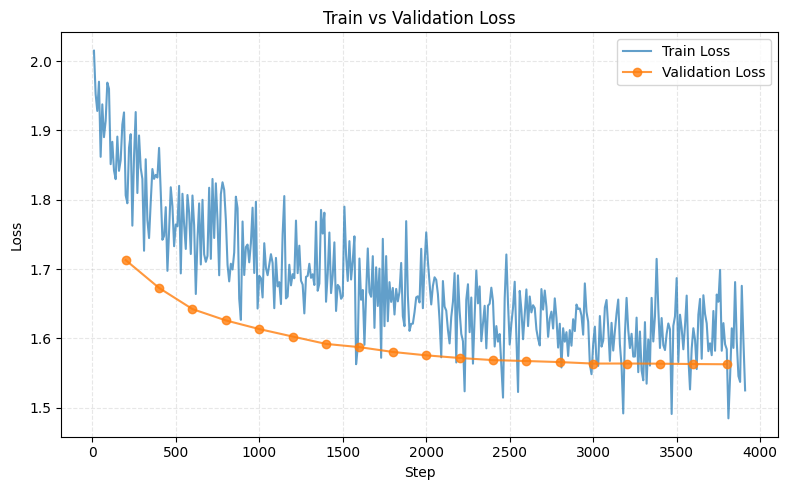

In [14]:
train_steps = [x['step'] for x in trainer.state.log_history if 'loss' in x and 'step' in x]
train_losses = [x['loss'] for x in trainer.state.log_history if 'loss' in x and 'step' in x]

eval_steps = [x['step'] for x in trainer.state.log_history if 'eval_loss' in x and 'step' in x]
eval_losses = [x['eval_loss'] for x in trainer.state.log_history if 'eval_loss' in x and 'step' in x]

train_steps, train_losses = zip(*sorted(zip(train_steps, train_losses)))
eval_steps, eval_losses = zip(*sorted(zip(eval_steps, eval_losses))) if eval_steps else ([], [])

plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_losses, label='Train Loss', alpha=0.7)
plt.plot(eval_steps, eval_losses, label='Validation Loss', marker='o', linestyle='-', alpha=0.8)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{picture_path}/train_val_loss.png", dpi=300, bbox_inches='tight')
plt.show()

# **Token Accuracy Curve**

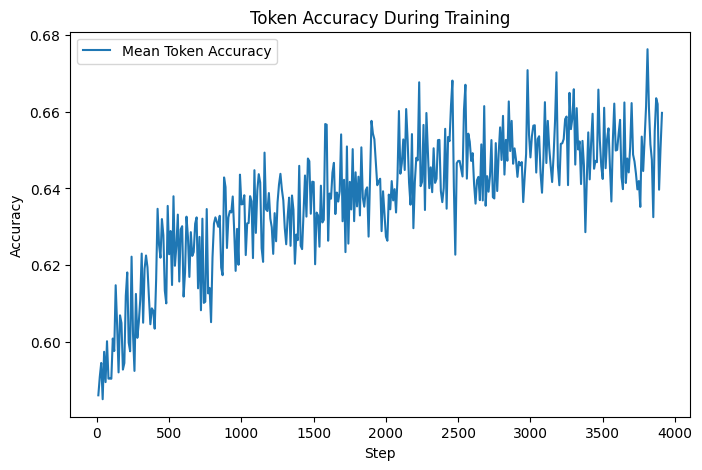

In [15]:
token_accs = [x['mean_token_accuracy'] for x in trainer.state.log_history if 'mean_token_accuracy' in x]

acc_steps = [x['step'] for x in trainer.state.log_history if 'mean_token_accuracy' in x]

plt.figure(figsize=(8,5))
plt.plot(acc_steps, token_accs, label='Mean Token Accuracy')
plt.xlabel('Step')
plt.ylabel('Accuracy')
plt.title('Token Accuracy During Training')
plt.legend()
plt.savefig(f"{picture_path}/token_accuracy.png", dpi=300, bbox_inches='tight')
plt.show()

# **Evaluate Model**

In [16]:
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

model.eval()

preds, refs = [], []
batch_size = 16

test_list = list(test_dataset)

for i in tqdm(range(0, len(test_list), batch_size), desc="Evaluating"):
    batch = test_list[i : i + batch_size]

    prompts = [build_prompt(ex['en']) for ex in batch]

    refs.extend([ex["vi"].strip() for ex in batch])

    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
            num_beams=1,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)

    batch_preds = [
        text.split("Vietnamese:")[-1].strip()
        for text in decoded
    ]

    preds.extend(batch_preds)

bleu_score = bleu.compute(
    predictions=preds,
    references=[[r] for r in refs]
)

rouge_score = rouge.compute(
    predictions=preds,
    references=refs
)

print(f"\nBLEU: {bleu_score['bleu']:.4f}")
print("ROUGE:")
for k, v in rouge_score.items():
    print(f" - {k}: {v:.4f}")

Evaluating: 100%|██████████| 125/125 [07:29<00:00,  3.59s/it]



BLEU: 0.2557
ROUGE:
 - rouge1: 0.6366
 - rouge2: 0.3897
 - rougeL: 0.5534
 - rougeLsum: 0.5533


# **Inference**

In [17]:
tokenizer = AutoTokenizer.from_pretrained(
    base_model_name,
    trust_remote_code=True
)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

model = PeftModel.from_pretrained(base_model, model_path)
model.eval()

english_text = "Hello, how are you today?"

prompt = build_prompt(english_text)

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=128,
        do_sample=False,
        num_beams=1,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

result = tokenizer.decode(outputs[0], skip_special_tokens=True)
translation = result.split("Vietnamese:")[-1].strip()

print("\nTranslation:")
print(translation)


Translation:
Bây giờ anh khỏe không?


# **Export Model**

In [18]:
def compress_folder(folder_path, zip_path):
    if not os.path.exists(folder_path):
        raise FileNotFoundError(f"Not found: {folder_path}")
    print(f"Compressing {folder_path} -> {zip_path}")
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
        for root, _, files in os.walk(folder_path):
            for f in files:
                file_path = os.path.join(root, f)
                arcname = os.path.relpath(file_path, folder_path)
                z.write(file_path, arcname)
                print(f"-> {arcname}")
    size_mb = os.path.getsize(zip_path) / (1024**2)
    print(f"Done: {zip_path} — {size_mb:.1f} MB\n")

compress_folder(model_path, model_zip)
compress_folder(picture_path, picture_zip)

Compressing ./qwen2.5-0.5b-lora-model -> qwen2.5-0.5b-lora-model.zip
-> README.md
-> vocab.json
-> adapter_config.json
-> training_args.bin
-> special_tokens_map.json
-> chat_template.jinja
-> adapter_model.safetensors
-> tokenizer_config.json
-> added_tokens.json
-> tokenizer.json
-> merges.txt
Done: qwen2.5-0.5b-lora-model.zip — 7.6 MB

Compressing ./picture -> picture.zip
-> token_accuracy.png
-> train_val_loss.png
Done: picture.zip — 0.5 MB

